<a href="https://colab.research.google.com/github/DrFaus/Estadistica2026B/blob/main/AtencionSolicitudes/Regresi%C3%B3nLinealMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de un Problema de regresión lineal múltiple.

##Descripción del conjunto de datos

El presente conjunto de datos corresponde a registros generados a partir del sistema de atención a solicitudes de soporte técnico de una empresa que opera una plataforma digital. Cada registro representa un ticket de soporte atendido por el equipo técnico, desde su recepción hasta su resolución.

La información contenida en la base de datos busca capturar tanto las condiciones operativas del sistema al momento de la solicitud, como ciertas características del proceso de atención y del tipo de usuario que genera el ticket. En este sentido, se incluyen variables relacionadas con el desempeño del sistema, la experiencia del personal asignado, el contexto en el que se recibe la solicitud y el canal de entrada del ticket.

Por otra parte, se incorporan variables que permiten clasificar a los usuarios según su tipo de servicio, así como priorizar las solicitudes en función de su relevancia operativa. Asimismo, se cuenta con un identificador único para cada ticket, el cual permite su trazabilidad dentro del sistema, pero no aporta información directa sobre el proceso de resolución.

Finalmente, el conjunto de datos incluye una variable que representa el tiempo requerido para resolver cada solicitud, medido en horas. Esta variable es de especial interés, ya que permite evaluar el desempeño del sistema de soporte y analizar los factores que pueden influir en la eficiencia del proceso de atención.

Es importante señalar que la base de datos no necesariamente refleja todas las variables que podrían influir en la resolución de un ticket, ya que existen factores adicionales —como la complejidad específica del problema o la disponibilidad de recursos en tiempo real— que no se encuentran registrados de manera explícita.

## Descripción de variables

- **ID del ticket**: Identificador único asignado a cada solicitud de soporte. Permite dar seguimiento al caso dentro del sistema y consultar su historial.

- **Carga del servidor**: Nivel de uso del sistema en el momento en que se genera el ticket, medido en porcentaje (%). Refleja la demanda operativa en ese instante.

- **Experiencia**: Experiencia del agente que atiende el ticket, medida en años. Representa el nivel de conocimiento del personal técnico.

- **Tiempo de diagnóstico**: Tiempo requerido para identificar el problema inicial, medido en minutos. Corresponde a la etapa previa a la resolución.

- **Cliente premium**: Indica si el usuario cuenta con un servicio preferencial (sí o no). Determina el nivel de atención que recibirá.

- **Prioridad**: Nivel de urgencia asignado al ticket (bajo, medio, alto). Se utiliza para organizar el orden de atención.

- **Canal de entrada**: Medio por el cual el cliente reporta el problema (web, correo, teléfono, chat). Representa la vía de contacto utilizada.

- **Tiempo de resolución**: Tiempo total requerido para resolver el ticket, medido en horas. Es un indicador del desempeño del sistema de soporte.

In [249]:
import pandas as pd

link = "https://raw.githubusercontent.com/DrFaus/Estadistica2026B/refs/heads/main/AtencionSolicitudes/datos_sinteticos.csv"

df = pd.read_csv(link)

df

,Unnamed: 0,ID del ticket,Carga del servidor,Experiencia,Tiempo de diagnóstico,Cliente premium,Prioridad,Canal de entrada,Tiempo de resolución
0,0,TK-100000-2008,48.09,7,40,sí,medio,web,32.3
1,1,TK-100001-2226,91.30,6,38,no,NaN,correo,37.6
2,2,TK-100002-2635,74.90,6,36,no,medio,chat,38.4
3,3,TK-100003-8261,64.90,3,44,no,medio,chat,48.1
4,4,TK-100004-9515,31.70,7,31,no,medio,web,NaN
...,...,...,...,...,...,...,...,...,...
2995,2995,TK-102995-7311,84.90,8,38,no,bajo,web,NaN
2996,2996,TK-102996-6531,31.80,5,32,no,alto,correo,24.7
2997,2997,TK-102997-3764,43.23,1,38,sí,bajo,correo,30.0
2998,2998,TK-102998-8008,41.75,1,40,no,medio,correo,36.7


### Cambiar nombres

Algunos procedimientos son sensibles a la presencia de espacios intermedios y caracteres especiales, como acentos, signos y la letra "ñ", por ejemplo. Para evitar estos problemas que se pueden presentar, se recomienta adaptar la base de datos a nombres más inocuos. Para esto podemos eliminar los acentos y cambiar espacios por guiones bajos. La letra "ñ" se suele cambiar por la combinación de letras "ni" o "gn".

Siempre les recomiendo que hagan el cambio de nombre desde github, porque así el cambio es permanente, y si después vuelven a llamar la base de datos en el mismo documento, ya no tienen que volver a hacer el cambio de nombres. Con el fin de que quede documentado el cambio de nombres, lo haré desde aquí, pero reafirmo mi recomendación.

In [250]:
# Imprimo los nombres de las columnas para copiar y pegar y evitar
# los errores tipográficos

df.columns

Index(['Unnamed: 0', 'ID del ticket', 'Carga del servidor', 'Experiencia',
       'Tiempo de diagnóstico', 'Cliente premium', 'Prioridad',
       'Canal de entrada', 'Tiempo de resolución'],
      dtype='object')

Aquí vemos una variable llamada `Unnamed: 0`. Esta variable es un residuo de una manipulación previa. Si la ven, elimínela sin pena.

Siempre usen como argumento `inplace=True`, están haciendo una reasignación. Están pidiendo que la acción que se acaba de hacer se guarde en el df original.

In [251]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df

,ID del ticket,Carga del servidor,Experiencia,Tiempo de diagnóstico,Cliente premium,Prioridad,Canal de entrada,Tiempo de resolución
0,TK-100000-2008,48.09,7,40,sí,medio,web,32.3
1,TK-100001-2226,91.30,6,38,no,NaN,correo,37.6
2,TK-100002-2635,74.90,6,36,no,medio,chat,38.4
3,TK-100003-8261,64.90,3,44,no,medio,chat,48.1
4,TK-100004-9515,31.70,7,31,no,medio,web,NaN
...,...,...,...,...,...,...,...,...
2995,TK-102995-7311,84.90,8,38,no,bajo,web,NaN
2996,TK-102996-6531,31.80,5,32,no,alto,correo,24.7
2997,TK-102997-3764,43.23,1,38,sí,bajo,correo,30.0
2998,TK-102998-8008,41.75,1,40,no,medio,correo,36.7


Ahora sí, procedemos con los cambios en los nombres:

In [252]:
# Cambiar nombres: fancy style
# Siguiendo un estilo en minusculas, cambiando espacios por _
# y evitando preposiciones y plurales innecesarios

# "Nombre Anterior": "nombre_actual"

df = df.rename(columns={
    'ID del ticket': "id_ticket",
    'Carga del servidor': "carga_servidor",
    'Experiencia': "experiencia",
    'Tiempo de diagnóstico': "tiempo_diagnostico",
    'Cliente premium': "premium",
    'Prioridad': "prioridad",
    'Canal de entrada': "canal_entrada",
    'Tiempo de resolución': "tiempo_resolucion"
})
df

,id_ticket,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
0,TK-100000-2008,48.09,7,40,sí,medio,web,32.3
1,TK-100001-2226,91.30,6,38,no,NaN,correo,37.6
2,TK-100002-2635,74.90,6,36,no,medio,chat,38.4
3,TK-100003-8261,64.90,3,44,no,medio,chat,48.1
4,TK-100004-9515,31.70,7,31,no,medio,web,NaN
...,...,...,...,...,...,...,...,...
2995,TK-102995-7311,84.90,8,38,no,bajo,web,NaN
2996,TK-102996-6531,31.80,5,32,no,alto,correo,24.7
2997,TK-102997-3764,43.23,1,38,sí,bajo,correo,30.0
2998,TK-102998-8008,41.75,1,40,no,medio,correo,36.7


En algunos casos les puede parecer innecesario el cambio de nombre, por ejemplo en `"Prioridad": "prioridad"`. Esto es algo que les recomiendo hacer, porque la mayoría de los errores por nombre (`NameError`) o por llave (`KeyError`) suelen ser por la confusión entre mayúsculas y minúsculas. Con cambiar todo a minúsculas se reduce la probabilidad de cometer estos errores.

Ahora la base de datos está lista para trabajarse.

### df.info()

El método `.info()` es muy importante para iniciar con la base de datos. Suele ser muy subestimado, porque la mayoría de las bases de datos que se trabajan a nivel didáctico están listas para iniciar con la regresión lineal. Pero nos da un panorama inicial de la base de datos que estamos trabajando.

Hay dos aspectos importantes de este método que veremos a continuación.

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_ticket           3000 non-null   object 
 1   carga_servidor      3000 non-null   float64
 2   experiencia         3000 non-null   int64  
 3   tiempo_diagnostico  3000 non-null   int64  
 4   premium             3000 non-null   object 
 5   prioridad           2700 non-null   object 
 6   canal_entrada       2700 non-null   object 
 7   tiempo_resolucion   2700 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 187.6+ KB


En las primeras líneas de la información nos aparece esto:
```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
```
Qué básicamente nos dice que el documento contiene 3000 entradas, o como también le llamamos, filas o registros. Por lo que deberíamos esperar que todas las variables tuvieran 3000 valores no nulos. Sin embargo tenemos las variables:

```
 #   Column              Non-Null Count  Dtype
 ...
 5   prioridad           2700 non-null   object
 6   canal_entrada       2700 non-null   object
 7   tiempo_resolucion   2700 non-null   float64
 ...
```

Que sólo tienen 2700 valores no nulos. Eso significa que hay `3000 - 2700 = 300` trecientos valores perdidos en cada una de estas columnas.

Las personas que trabajan haciendo limpieza de datos, tienen muchas estrategias para conservar la mayor cantidad de datos posible. Dado que esa no es nuestra tarea, nos vamos por la opción más simple. Además, estamos haciendo regresión lineal, que no se ve afectada por una reducción de datos. La solución es utilizar el método `.dropna()` como vemos a continuación.


In [254]:
df.dropna(inplace = True)
df

,id_ticket,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
0,TK-100000-2008,48.09,7,40,sí,medio,web,32.3
2,TK-100002-2635,74.90,6,36,no,medio,chat,38.4
3,TK-100003-8261,64.90,3,44,no,medio,chat,48.1
5,TK-100005-8529,31.70,5,42,no,bajo,web,35.6
6,TK-100006-2685,24.36,4,22,no,alto,web,26.0
...,...,...,...,...,...,...,...,...
2994,TK-102994-7199,29.88,4,19,no,alto,chat,16.2
2996,TK-102996-6531,31.80,5,32,no,alto,correo,24.7
2997,TK-102997-3764,43.23,1,38,sí,bajo,correo,30.0
2998,TK-102998-8008,41.75,1,40,no,medio,correo,36.7


Si ahora volvemos a hacer `df.info()` vemos que ahora sí tendrémos tantas entradas como valores por variable:

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2188 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_ticket           2188 non-null   object 
 1   carga_servidor      2188 non-null   float64
 2   experiencia         2188 non-null   int64  
 3   tiempo_diagnostico  2188 non-null   int64  
 4   premium             2188 non-null   object 
 5   prioridad           2188 non-null   object 
 6   canal_entrada       2188 non-null   object 
 7   tiempo_resolucion   2188 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 153.8+ KB


El otro aspecto importante de `df.info()` es que nos dice qué tipo de datos tiene cada columna/variable. Típicamente distinguimos tres tipos: int64 que es un entero, float64 que es un flotante (decimal) y object que es una cadena de caracteres, lo que podemos clasificar como "variable categórica". En el caso de que la variable sea del tipo numérico `int64` o `float64`, la analizamos mediante histogramas para conocer si distribución aproximada y si hay datos atípicos. En el caso de que se trate de vaariables categóricas o tipo `object` las trabajaremos con 3 estrategias distintas que veremos más adelante.

### ID del ticket

Citamos lo siguiente de la descripción:

**ID del ticket**: Identificador único asignado a cada solicitud de soporte. Permite dar seguimiento al caso dentro del sistema y consultar su historial.

Y consultando `df.info()` tenemos lo siguiente:


```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_ticket           2188 non-null   object
```

Lo que nos dice que es una variable categórica. Dado que se trata de un identificador único, entonces tendremos un valor distinto por cada registro, lo que hace que esta variable no la podamos trabajar. Cualquier gráfico que intentemos hacer con esta variable, va a requerir un esfuerzo de cómputo muy grande. Si la computadora tarda demasiado en dar una respuesta, es una pista importante de que quizá deberíamos desechar la variable. Se echar una mirada exploratoria usando `.unique()` que extrae los valores únicos de la variable y `.size` que nos dice el tamaño de cualquier cosa.

In [256]:
df["id_ticket"].unique().size

2188

Por esta razón, desechamos la variable.

In [257]:
df.drop(columns = ["id_ticket"], inplace = True)
df

,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
0,48.09,7,40,sí,medio,web,32.3
2,74.90,6,36,no,medio,chat,38.4
3,64.90,3,44,no,medio,chat,48.1
5,31.70,5,42,no,bajo,web,35.6
6,24.36,4,22,no,alto,web,26.0
...,...,...,...,...,...,...,...
2994,29.88,4,19,no,alto,chat,16.2
2996,31.80,5,32,no,alto,correo,24.7
2997,43.23,1,38,sí,bajo,correo,30.0
2998,41.75,1,40,no,medio,correo,36.7


### Carga del servidor

Citando la descripción de variables, tenemos:

**Carga del servidor**: Nivel de uso del sistema en el momento en que se genera el ticket, medido en porcentaje (%). Refleja la demanda operativa en ese instante.

Y extrayendo la información que nos da `df.info()`:


```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 1   carga_servidor      2188 non-null   float64
 ...
```

El tipo `float64` significa que es una variable numérica que está en decimales. Por lo que el análisis inicial será a partir de un histograma.

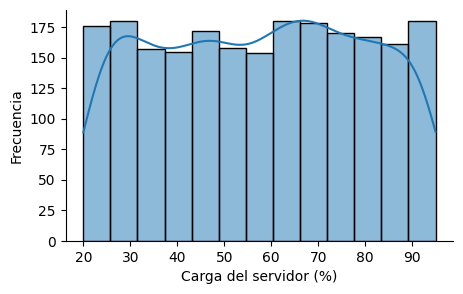

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['carga_servidor'], kde=True)
plt.xlabel("Carga del servidor (%)")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

Se observa una distribución uniforme sin datos atípicos. Dejamos en paz a esta variable, todo está bien, seguimos adelante.

### Experiencia

Citamos la descripción de la variable:

**Experiencia**: Experiencia del agente que atiende el ticket, medida en años. Representa el nivel de conocimiento del personal técnico.

Y lo que nos dice `df.info()` sobre esta variable:


```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 2   experiencia         2188 non-null   int64
 ...
```

Debido a que `int64` indica que la columna contiene valores enteros, inferimos que es una variable numérica discreta. Igual la analizamos con un histograma.



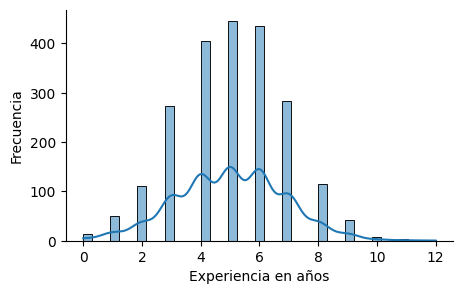

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['experiencia'], kde=True)
plt.xlabel("Experiencia en años")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

Los datos se ajustan a una distribución normal y no se pueden observar datos atípicos. Podemos continuar con la siguiente variable.

### Tiempo de diagnóstico

Haciendo referencia a su descripción:

**Tiempo de diagnóstico**: Tiempo requerido para identificar el problema inicial, medido en minutos. Corresponde a la etapa previa a la resolución.

Y lo que nos dice `df.info()`:

```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 3   tiempo_diagnostico  2188 non-null   int64  
 ...
```

Igual que la variable anterior, es una variable numérica discreta, dado que `int64` significa que la variable contiene sólo valores enteros. Con esta información, la analizamos mediante un histograma.


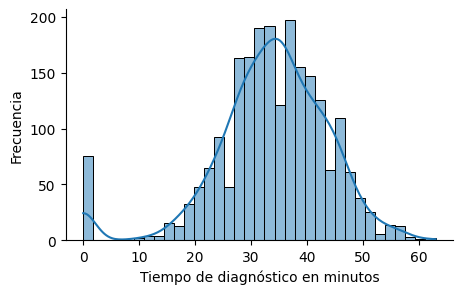

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['tiempo_diagnostico'], kde=True)
plt.xlabel("Tiempo de diagnóstico en minutos")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

Vemos que la variable sigue una distribución normal, sin embargo, se ve una barra fuera de lugar. El lado izquierdo de la gráfica. Esto nos señala la precencia de valores atípicos.

Los valores atípicos se detectan por estas barras que sobresalen y rompen con la distribución de los demás datos. En sí, es posible que un diagnóstico se haya hecho en cero minutos (lo que señala el histograma) pero dado que los demás datos no acompañan este valor, es más probable que se trate de un valor que no debería estar ahí.

A veces, las personas que capturan los datos, olvidan capturar ciertos datos o por alguna razón no fue posible hacerlo, y tienen dos opciones. Una es dejarlos en blanco, lo que nosotros interpretamos como NaN, o pueden escribir un valor absurdo, tal que deja en claro al analista que el dato no fue capturado. A estos valores se les llama "valor centinela". Y aunque se recomienda no usar estos valores, en ocaciones el programa no permite el registro a menos que se ingrese el valor. Hay que estar muy atento a la precensia de estos datos y eliminarlos cuando se presentan.

En este caso sabemos que un diagnóstico en cero minutos es imposible, entonces nos quedamos con los valores que sean mayores a cero.

In [261]:
df = df[df["tiempo_diagnostico"] > 0]

Observa que reasignamos `df` a sólo los valores en que la variable `tiempo_diagnostico` tiene valores superiores a `0`. Ahora, volvemos a hacer el histograma y vemos que los valores atípicos han desaparecido.

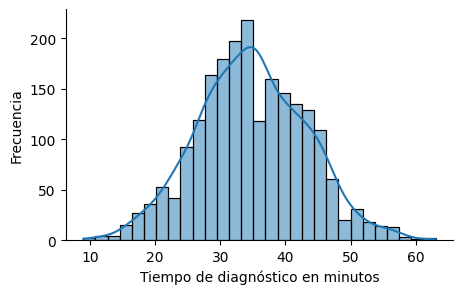

In [262]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['tiempo_diagnostico'], kde=True)
plt.xlabel("Tiempo de diagnóstico en minutos")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

Este procedimiento tiene un costo, hemos perdido más datos. Por lo que debe considerarse la importancia de la variable. Si la variable es importante, se debe hacer este procedimiento. Si la variable no es importante, entonces podría ser mejor eliminar la variable con tal de no perder registros. Es un análisis personal de costo-beneficio. Observamos con `df.info()` cómo quedó el dataframe después de la perdida de información.

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2113 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   carga_servidor      2113 non-null   float64
 1   experiencia         2113 non-null   int64  
 2   tiempo_diagnostico  2113 non-null   int64  
 3   premium             2113 non-null   object 
 4   prioridad           2113 non-null   object 
 5   canal_entrada       2113 non-null   object 
 6   tiempo_resolucion   2113 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 132.1+ KB


Antes teníamos 2188 entradas, ahora nos quedan 2113. La perdida de información no fue tan grande. Seguimos adelante.

### Cliente premium

Citando su descripción, tenemos:

**Cliente premium**: Indica si el usuario cuenta con un servicio preferencial (sí o no). Determina el nivel de atención que recibirá.

Y su descripción de `df.info()`:

```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 3   premium             2113 non-null   object
 ...
```

Nos damos cuenta que al ser del tipo `object` se trata de una variable categórica. Vemos primero cuántos valores únicos tiene.



In [264]:
df["premium"].unique().size

2

Con sólo dos valores únicos, nos damos cuenta que es una variable categórica que se puede trabajar. Además, se trata de una variable categórica binaria. Realizamos un gráfico de pastel:

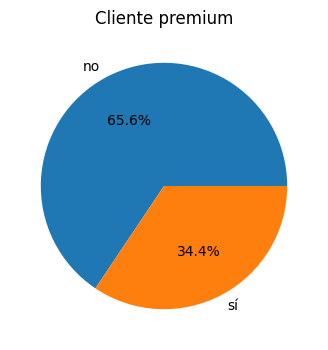

In [265]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(4,4),
    dpi=100
)

# Contar categorías de una columna
conteo = df["premium"].value_counts()

# Graficar
plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%')

plt.title("Cliente premium")
plt.show()

Vemos que los valores posibles son: `sí` y `no`. Con dos valores, la codificación puede hacerse de cualquier forma y no va a afectar el resultado. Anteriormente, en otro trabajo, nos encontramos con la variable `genero` e hicimos Tukey para saber a cuál valor le ibamos a dar el cero y a cual el 1. Este procedimiento, aunque innecesario, es una buena práctica. Salvo cuando nos encontramos con este tipo de variables binarias. En este caso, lo más adecuado es darle a `no` el valor de cero y a `sí` el valor de 1, dado que esta codificación es tan típica en la práctica, que ya se infiere sin necesidad de documentación. Ir en contra de una práctica tan generalizada puede ser fuente de error o confusión. Entonces, de forma ciega, asígnamos a `No` el valor de cero y a `Yes` el valor de 1.

In [266]:
df["premium"] = df["premium"].map({
    "no": 0,
    "sí": 1
})

df

/tmp/ipykernel_9066/3195766222.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["premium"] = df["premium"].map({


,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
0,48.09,7,40,1,medio,web,32.3
2,74.90,6,36,0,medio,chat,38.4
3,64.90,3,44,0,medio,chat,48.1
5,31.70,5,42,0,bajo,web,35.6
6,24.36,4,22,0,alto,web,26.0
...,...,...,...,...,...,...,...
2994,29.88,4,19,0,alto,chat,16.2
2996,31.80,5,32,0,alto,correo,24.7
2997,43.23,1,38,1,bajo,correo,30.0
2998,41.75,1,40,0,medio,correo,36.7


Podemos repetir el gráfico de pastel para asegurarnos de que todo salió bien. El gráfico debe ser exactamente igual al anterior en términos de proporción, de otra forma, la codificación no se completó adecuadamente, seguramente por un error tipográfico. Si estás seguro de que lo hiciste bien, puedes omitir este paso.

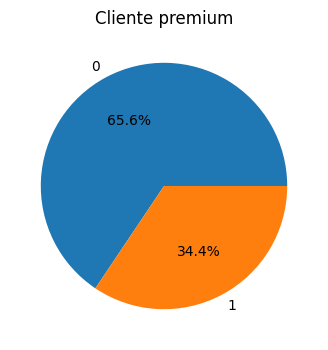

In [267]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(4,4),
    dpi=100
)

# Contar categorías de una columna
conteo = df["premium"].value_counts()

# Graficar
plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%')

plt.title("Cliente premium")
plt.show()

### Prioridad

Su descripción es:

**Prioridad**: Nivel de urgencia asignado al ticket (bajo, medio, alto). Se utiliza para organizar el orden de atención.

Y la descripción que nos da `df.info()` es:

```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 4   prioridad           2113 non-null   object
 ...
```

Entonces, por `object` sabemos que es una variable categórica. Vemos cuántos valores únicos tiene:

In [268]:
df["prioridad"].unique().size

3

Sólo hay tres datos distintos, entonces se puede trabajar esta variable. Hacemos un gráfico de pastel:

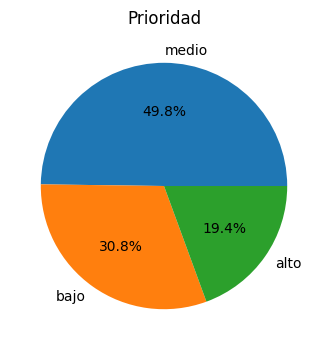

In [269]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(4,4),
    dpi=100
)

# Contar categorías de una columna
conteo = df["prioridad"].value_counts()

# Graficar
plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%')

plt.title("Prioridad")
plt.show()

Así que, sin necesidad de hacer el test de Tukey podemos asignarle valores numéricos.


```
"bajo": 0,
"medio": 1,
"alto": 2
```

Dado que se trata de una variable categórica ordinal. Este tipo de variables tienen un orden implícito (orden jerárquico: bajo, medio, alto). Generalmente, usamos el test de Tukey como guía para establecer un orden, pero si este orden ya existe, lo mejor es respetarlo. A algunas personas les gusta hacer la codificación de la siguiente manera:

```
"bajo": -1,
"medio": 0,
"alto": 1
```

Debido que es lo que se hace en diseños experimentales, pero en regresión lineal hay más libertad al respecto.

In [270]:
df['prioridad'] = df["prioridad"].map({
    "bajo": 0,
    "medio": 1,
    "alto": 2
})
df

/tmp/ipykernel_9066/3333507170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prioridad'] = df["prioridad"].map({


,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
0,48.09,7,40,1,1,web,32.3
2,74.90,6,36,0,1,chat,38.4
3,64.90,3,44,0,1,chat,48.1
5,31.70,5,42,0,0,web,35.6
6,24.36,4,22,0,2,web,26.0
...,...,...,...,...,...,...,...
2994,29.88,4,19,0,2,chat,16.2
2996,31.80,5,32,0,2,correo,24.7
2997,43.23,1,38,1,0,correo,30.0
2998,41.75,1,40,0,1,correo,36.7


Repetimos el gráfico de pastel para asegurarnos de que todo salió bien.

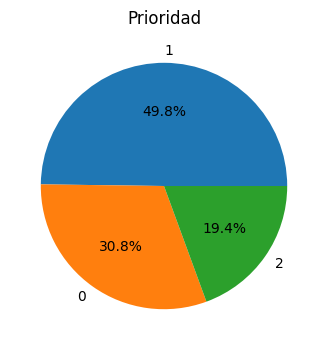

In [271]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(4,4),
    dpi=100
)

# Contar categorías de una columna
conteo = df["prioridad"].value_counts()

# Graficar
plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%')

plt.title("Prioridad")
plt.show()

### Canal de entrada

La descripción de la variable es:

**Canal de entrada**: Medio por el cual el cliente reporta el problema (web, correo, teléfono, chat). Representa la vía de contacto utilizada.

Y la descripción de `df.info()` es:

```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 5   canal_entrada       2113 non-null   object
 ...
```

Por lo que la variable es categórica. Vemos cuántos valores únicos tiene:


In [272]:
df['canal_entrada'].unique().size

4

Con sólo cuatro valores vemos que es una variable categórica que se puede trabajar. Hacemos el gráfico de pastel.

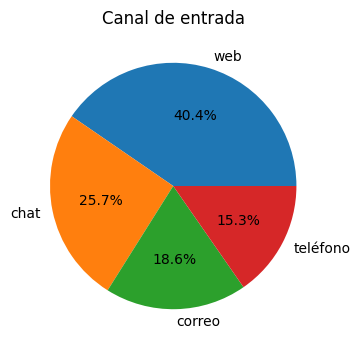

In [273]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(4,4),
    dpi=100
)

# Contar categorías de una columna
conteo = df["canal_entrada"].value_counts()

# Graficar
plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%')

plt.title("Canal de entrada")
plt.show()

A diferencia de las variables categóricas tratadas anteriormente, esta no es binaria ni ordinal sino nominal. No hay un orden jerárquico implícito. No se sabe si correo es mayor que teléfono o viceversa. Aquí sí es importante apoyarnos en una herramienta adicional. Aquí está justificado usar el test de Tukey para saber cómo ordenar estos valores.

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
    chat   correo  -2.2592    0.0 -3.5227 -0.9957   True
    chat teléfono   -3.701    0.0 -5.0402 -2.3617   True
    chat      web   1.9857    0.0  0.9384   3.033   True
  correo teléfono  -1.4417 0.0475 -2.8728 -0.0107   True
  correo      web   4.2449    0.0  3.0825  5.4074   True
teléfono      web   5.6867    0.0  4.4423   6.931   True
--------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

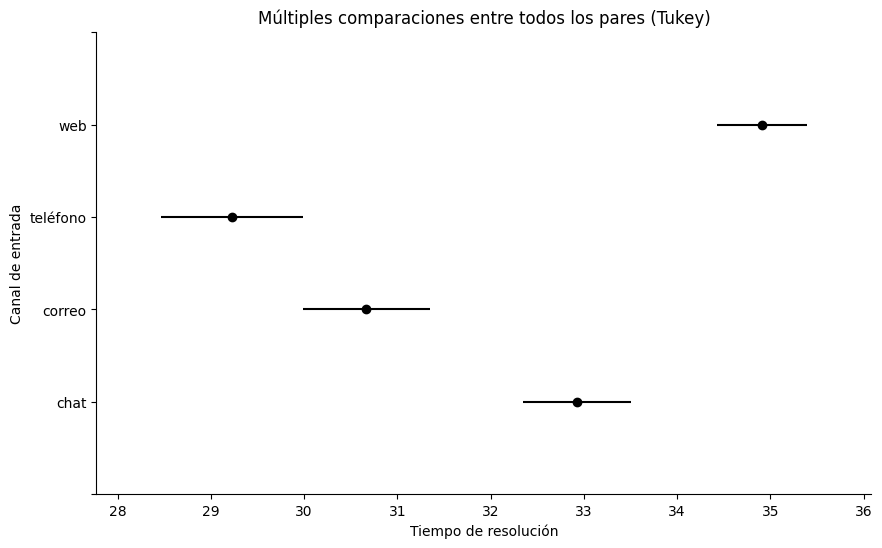

In [274]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['tiempo_resolucion'], # Variable de respuesta
    groups=df['canal_entrada'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Canal de entrada", xlabel="Tiempo de resolución")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Con esto, podemos establecer un orden de izquierda a derecha, y usar este orden para codificar la variable categórica nominal a una variable numérica discreta.

In [275]:
df["canal_entrada"] = df["canal_entrada"].map({
    "teléfono": 0,
    "correo": 1,
    "chat": 2,
    "web": 3
})

df

/tmp/ipykernel_9066/894609041.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["canal_entrada"] = df["canal_entrada"].map({


,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
0,48.09,7,40,1,1,3,32.3
2,74.90,6,36,0,1,2,38.4
3,64.90,3,44,0,1,2,48.1
5,31.70,5,42,0,0,3,35.6
6,24.36,4,22,0,2,3,26.0
...,...,...,...,...,...,...,...
2994,29.88,4,19,0,2,2,16.2
2996,31.80,5,32,0,2,1,24.7
2997,43.23,1,38,1,0,1,30.0
2998,41.75,1,40,0,1,1,36.7


Podemos repetir el test de Tukey para verificar que todo se hizo bien.


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     0      1   1.4417 0.0475 0.0107 2.8728   True
     0      2    3.701    0.0 2.3617 5.0402   True
     0      3   5.6867    0.0 4.4423  6.931   True
     1      2   2.2592    0.0 0.9957 3.5227   True
     1      3   4.2449    0.0 3.0825 5.4074   True
     2      3   1.9857    0.0 0.9384  3.033   True
--------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

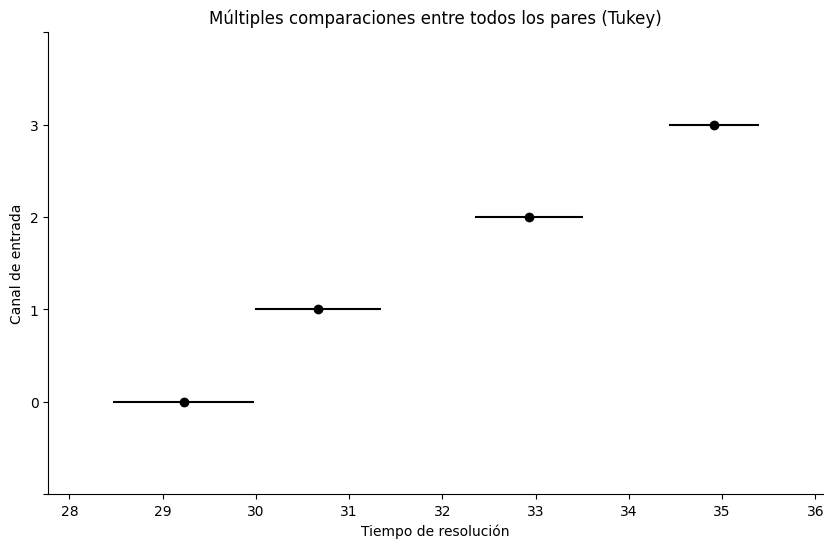

In [276]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['tiempo_resolucion'], # Variable de respuesta
    groups=df['canal_entrada'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Canal de entrada", xlabel="Tiempo de resolución")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Cambio el orden, pero de ahí en más, todo bien.

Aquí debo hacer una aclaración. Alguien que sepa del tema les podrá decir que el test de Tukey es totalmente innecesario, y tendrán razón. Lo único que nos importa es el orden de las medias de cada grupo y para eso podriamos hacer algo como:


```
df.groupby("canal_entrada")["tiempo_resolucion"].mean()
```

Y con la información que nos da este código, hacer la codificación. Sin embargo, Tukey es muy importante en las unidades siguientes. Así que, no lo incorporo porque sea necesario, sino porque además de dar una representación gráfica de lo que estamos haciendo, nos permite familiarizarnos con una herramienta que será muy importante en próximas unidades.

### Tiempo de resolución

Esta variable es la más importante, dado que es el propósito del estudio. Es la variable dependiente, o como también se le llama, variable de respuesta. Se describe como se muestra a continuación:

**Tiempo de resolución**: Tiempo total requerido para resolver el ticket, medido en horas. Es un indicador del desempeño del sistema de soporte.

y según `df.info()`

```
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 ...
 6   tiempo_resolucion   2113 non-null   float64
```

El tipo `float64` nos indica que es un valor numérico continuo con números decimales. Entonces la analizamos mediante un histograma.

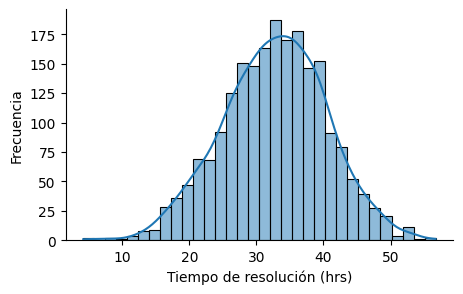

In [277]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['tiempo_resolucion'], kde=True)
plt.xlabel("Tiempo de resolución (hrs)")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

La variable sigue una distribución normal sin valores atípicos. No hay más que hacer. Continuamos con el análisis.

## Mapa de calor (matriz de correlación)

Ahora todas las variables tienen valores numéricos. Entonces ya se puede hacer un mapa de calor que incorpore a todas las variables.

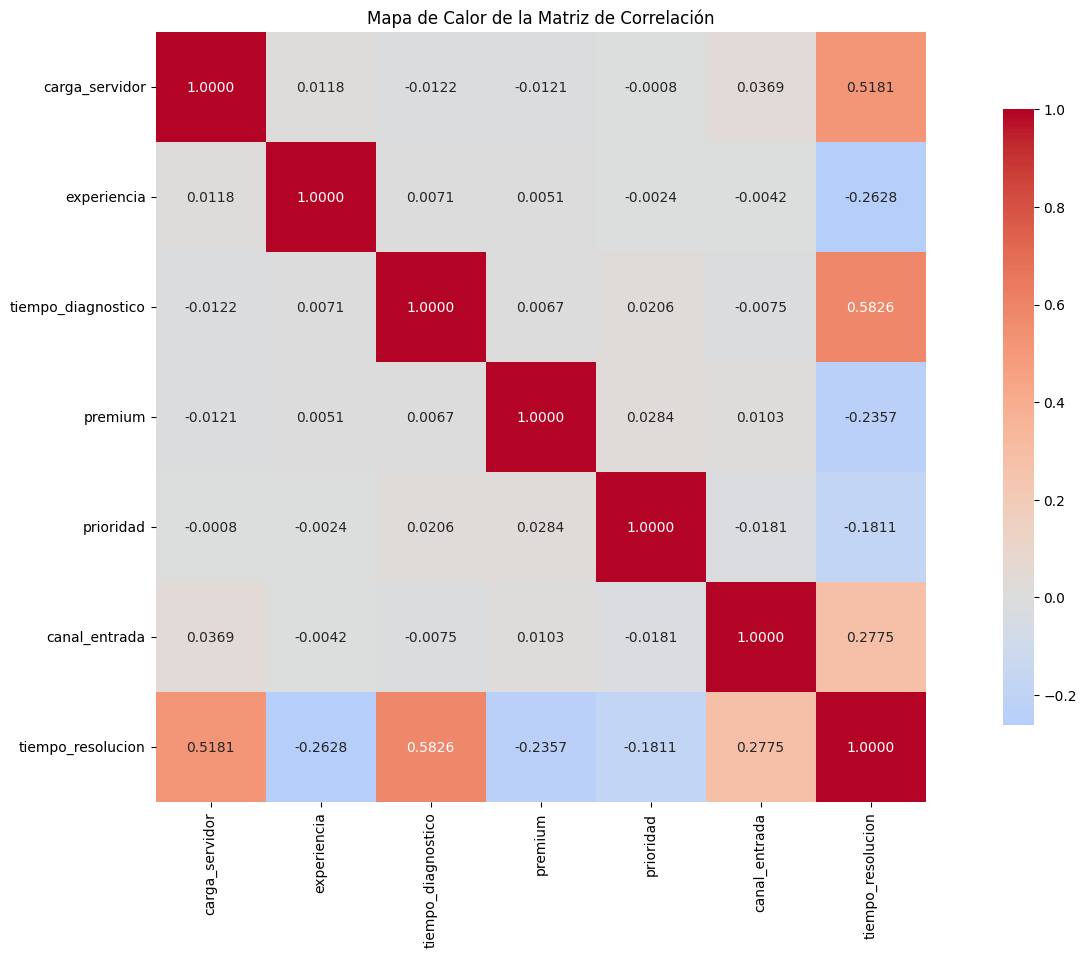

In [278]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Calcula la matriz de correlación entre variables numéricas del DataFrame
correlation_matrix = df.corr()

plt.figure(
    figsize=(20, 10), # Define el tamaño de la figura (ancho, alto)
    dpi = 100  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

Llegados aquí, tengo que señalar algo muy importante. He buscado mucho una base de datos que nos permitiera analizar todo lo que se debe analizar en una base de datos y no la encontré, por lo que estos datos son sintéticos. Los fabriqué para el ejercicio y poder plasmar todo lo que se requiere. Pero aquí estamos pagando el precio. A pesar de que le metí muchos detalles de forma intensional, sigue siendo demasiado perfecta. Vemos que prácticamente no se presenta multicolinealidad (alta correlación entre variables independientes), cosa que en la práctica es improbable. Así que, ni modo, por el momento nos quedaremos sin el análisis de multicolinealidad. Pero podemos saltar a ANOVA

## Test ANOVA

El nombre ANOVA viene de (**AN**alysis **O**f **VA**riance). Esta herramienta es de las más importantes de la estadística y la veremos a profundidad en las siguientes unidades. Por el momento, nos ayuda a conocer el efecto de las variables por estimar la variable dependiente.

In [279]:
# lazytrick
# sólo recuerda quitar la variable de respuesta
' + '.join(df.columns)

'carga_servidor + experiencia + tiempo_diagnostico + premium + prioridad + canal_entrada + tiempo_resolucion'

In [280]:
# 12. Realice una tabla ANOVA e interprete el resultado.

# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
    '''tiempo_resolucion ~ carga_servidor + experiencia
                          + tiempo_diagnostico + premium + prioridad
                          + canal_entrada''',
    data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
carga_servidor,1.0,33763.337702,33763.337702,3687.839192,0.000000e+00
experiencia,1.0,9099.142239,9099.142239,993.864222,5.064758e-179
tiempo_diagnostico,1.0,43917.379938,43917.379938,4796.926073,0.000000e+00
premium,1.0,6764.283417,6764.283417,738.836596,1.027128e-139
prioridad,1.0,4401.542591,4401.542591,480.763526,3.745408e-96
canal_entrada,1.0,8543.668273,8543.668273,933.191943,5.668126e-170
Residual,2106.0,19281.098089,9.155317,NaN,NaN


El hecho de que haya una baja multicolinealidad, hace que todas las variables sean importantes, y por lo tanto, no podamos eliminar ninguna. Podemos ver esto de otra manera, midiendo el tamaño del efecto. Lo que podemos ver con el siguiente código poniendo atención a la columna `eta_sq_parcial` que se representa como $\eta ^2$ y tiene una interpretación muy similar a la que tiene $R^2$.

In [281]:
anova = sm.stats.anova_lm(modelo_lineal)

ss_total = anova["sum_sq"].sum()
ss_residual = anova.loc["Residual", "sum_sq"]

anova["eta_sq"] = anova["sum_sq"] / ss_total
anova["eta_sq_parcial"] = anova["sum_sq"] / (anova["sum_sq"] + ss_residual)

anova

,df,sum_sq,mean_sq,F,PR(>F),eta_sq,eta_sq_parcial
carga_servidor,1.0,33763.337702,33763.337702,3687.839192,0.000000e+00,0.268452,0.636510
experiencia,1.0,9099.142239,9099.142239,993.864222,5.064758e-179,0.072347,0.320615
tiempo_diagnostico,1.0,43917.379938,43917.379938,4796.926073,0.000000e+00,0.349187,0.694912
premium,1.0,6764.283417,6764.283417,738.836596,1.027128e-139,0.053783,0.259711
prioridad,1.0,4401.542591,4401.542591,480.763526,3.745408e-96,0.034997,0.185855
canal_entrada,1.0,8543.668273,8543.668273,933.191943,5.668126e-170,0.067931,0.307053
Residual,2106.0,19281.098089,9.155317,NaN,NaN,0.153304,0.500000


Con esto vemos que la variable más importante es `tiempo_diagnostico` con un tamaño de efecto de 0.693297. Esto ya permite dar una recomendación a la empresa. Diciéndoles que reducir el tiempo de diagnóstico puede tener un efecto muy positivo en el tiempo de resolución. Y aunque la variable `carga_servidor` le sigue en orden de importancia, quizá la empresa no tenga mucho control sobre esta variable.

Con esta información, no podemos descartar niguna variable, todas son importantes y la empresa puede tener acceso a todas para realizar una predicción. Así que seguimos con la construcción del modelo.

## Modelo de regresión lineal múltiple.

A esta altura, ya sabemos cuales son las variables independientes y cual es la variable dependiente. Sólo falta definirlo mediante `x` y `y`:

In [282]:
df.columns

Index(['carga_servidor', 'experiencia', 'tiempo_diagnostico', 'premium',
       'prioridad', 'canal_entrada', 'tiempo_resolucion'],
      dtype='object')

In [283]:
x = df[[
    'carga_servidor', 'experiencia', 'tiempo_diagnostico', 'premium',
       'prioridad', 'canal_entrada'
]]

y = df['tiempo_resolucion']

Ahora generamos la variable `x` con una constante:

In [284]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)

x_constante

,const,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada
0,1.0,48.09,7,40,1,1,3
2,1.0,74.90,6,36,0,1,2
3,1.0,64.90,3,44,0,1,2
5,1.0,31.70,5,42,0,0,3
6,1.0,24.36,4,22,0,2,3
...,...,...,...,...,...,...,...
2994,1.0,29.88,4,19,0,2,2
2996,1.0,31.80,5,32,0,2,1
2997,1.0,43.23,1,38,1,0,1
2998,1.0,41.75,1,40,0,1,1


Vemos que el DataFrame `x_constante` es casi igual al que definimos en `x`. La única diferencia es que `x_constante` agrega una columna hasta la izquierda con valores unitarios. Este proceso es muy simple pero indispensable para afinar el modelo y para aplicar el test de Breush-Pagan más adelante. Ahora sí, afinamos el modelo:

In [285]:
import statsmodels.api as sm
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,8.211668
carga_servidor,0.183053
experiencia,-1.147442
tiempo_diagnostico,0.553305
premium,-3.728965
prioridad,-2.012249
canal_entrada,1.840673


Con esto, tenemos a un modelo entrenado, al cual de manera poco creativa hemos llamado `modelo`. Este modelo es un objeto, por lo que tiene propiedades y puede realizar acciones. Por el momento, nos interesa la propiedad `.params` que nos devuelve las columnas de `x_constante` con sus respectivos multiplicadores.

+ **const**: Siempre tiene el valor de 1.0
+ **carga_servidor**: Es el porcentaje de saturación que tiene el servidor, por lo que sólo puede tener valores entre 0 y 100.
+ **experiencia**: Son los años de experiencia del agente. Haciendo `df.describe()` como se muestra a continuación, sabemos que esta variable tiene valores entre 0 y 12.
+ **tiempo_diagnostico**: El tiempo que tarda en hacerse el diagnóstico en minutos, por `df.describe()` sabemos que tiene valores entre 9 y 63.
+ **premium**: Indica si el cliente cuenta con servicio premium. Tiene valor de `0` para `no` y `1` para `sí`.
+ **prioridad**: El nivel de prioridad para resolver el problema. Tiene tres valores posibles: `0` para `bajo`, `1` para `medio` y `2` para `alto`.
+ **canal_entrada**: Es el medio por el cual se hizo la solicitud. Aquí tenemos cuatro valores posibles:

```
    "teléfono": 0,
    "correo": 1,
    "chat": 2,
    "web": 3
```
Si se conocen estos valores, el modelo usará la ecuación siguiente para realizar predicciones:

$$
\text{tiempo_resolucion} =
8.423654
+ 0.183112 \cdot \text{carga_servidor}
- 1.146077 \cdot \text{experiencia}
+ 0.552018 \cdot \text{tiempo_diagnostico}
- 3.735211 \cdot \text{premium}
- 1.237109 \cdot \text{prioridad}
+ 1.837540 \cdot \text{canal_entrada}
$$


In [286]:
df.describe()

,carga_servidor,experiencia,tiempo_diagnostico,premium,prioridad,canal_entrada,tiempo_resolucion
count,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000
mean,57.668547,5.002366,34.808329,0.344061,0.885944,1.911500,32.740511
std,21.755301,1.824832,8.341134,0.475173,0.699537,1.093726,7.716891
min,20.000000,0.000000,9.000000,0.000000,0.000000,0.000000,4.200000
25%,38.640000,4.000000,29.000000,0.000000,0.000000,1.000000,27.600000
50%,58.550000,5.000000,35.000000,0.000000,1.000000,2.000000,33.000000
75%,76.120000,6.000000,41.000000,1.000000,1.000000,3.000000,38.200000
max,94.980000,12.000000,63.000000,1.000000,2.000000,3.000000,56.700000


Si quieren conocer más sobre el modelo, pueden ejecutar:

```
modelo.summary()
```

Y les dará una descripción detallada del modelo. De hecho, esta descripción del modelo es tan buena, que les devuelve el coeficiente de determinación $R^2$, prueba de normalidad, ANOVA, tamaño de efectos, intervalos de confianza, multicolinealidad, y hasta prueba de independencia (util en series de tiempo), en fin, prácticamente todo el análisis. Pueden copiar el resultado y pasarselo a chatGPT para que se los interprete. De hecho, por esta razón no les había comentado este detalle, sorry.

Lo único que no hace es el test de Breusch-Pagan.

In [287]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      tiempo_resolucion   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     1939.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:13:48   Log-Likelihood:                -5334.2
No. Observations:                2113   AIC:                         1.068e+04
Df Residuals:                    2106   BIC:                         1.072e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.2117      0.404     20.316      0.000       7.419       9.004
carga_servidor         0.1831      0.003     60.431      0.000       0.177       0.189
experiencia           -1.1474      0.036    -31.799      0.000      -1.218      -1.077
tiempo_diagnostico     0.5533      0.008     70.072      0.000       0.538       0.569
premium               -3.7290      0.139    -26.897      0.000      -4.001      -3.457
prioridad             -2.0122      0.094    -21.363      0.000      -2.197      -1.828
canal_entrada          1.8407      0.060     30.548      0.000       1.723       1.959
==============================================================================
Omnibus:                        3.224   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.199   Jarque-Bera (JB):                3.258
Skew:                           0.058   Prob(JB):                        0.196
Kurtosis:                       3.153   Cond. No.                         433.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Ejemplo de aplicación

Si el servidor está tiene una carga del 80%, el agente que atiende tiene 5 años de experiencia, se realizó un diagnóstico en 37 minutos, se trata de un cliente premium, tiene un nivel de prioridad alto, y se comunicó con la empresa por teléfono, entonces tenemos las variables:

```
const = 1
carga_servidor = 80
experiencia = 5
tiempo_diagnostico = 37
premium = 1
prioridad = 2
canal_entrada = 0
```

Esto se pasa a un vector en el orden que se declararon las variables independientes:


```
[1, 80, 5, 37, 1, 2, 0]
```

Y este vector se lo pasamos a `modelo.predict()`



In [288]:
modelo.predict([1, 80, 5, 37, 1, 2, 0])

array([29.83755691])

Con lo que el modelo nos dice que el tiempo de resolución será de aproximadamente 29.84 horas. Aunque `.get_prediction()` nos puede dar un análisis más completo.

In [296]:
modelo.get_prediction([1, 80, 5, 37, 1, 2, 0]).summary_frame(alpha = 0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,29.837557,0.204058,29.43738,30.237733,23.890257,35.784857


In [298]:
# Fancy mode

import pandas as pd

nivel_de_confianza = 0.95

nuevo = pd.DataFrame({
    "const": [1],
    "carga_servidor": [80],
    "experiencia": [5],
    "tiempo_diagnostico": [37],
    "premium": [1],
    "prioridad": [2],
    "canal_entrada": [0]
})

pred = modelo.get_prediction(nuevo)
pred.summary_frame(alpha = 1 - nivel_de_confianza)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,29.837557,0.204058,29.43738,30.237733,23.890257,35.784857


En la columna `mean`vamos a encontrar el mismo valor que nos da `.predict`, pero `.get_prediction()` va más allá, y mediante las columnas `mean_ci_lower` y `mean_ci_upper` nos da un intervalo de confianza para el promedio del tiempo de resolución y mediante las columnas `obs_ci_lower` y `obs_ci_upper` nos dice el intervalo de confianza para un caso específico. Por ejemplo, aquí estámos 95% seguros de que el tiempo de resolución estará entre `23.89` y `35.78` horas.

Con esta información, la empresa puede decidir si le da trato preferencial a este cliente para reducir el tiempo de resolución o prometerle al cliente un tiempo de resolución más preciso. Por ejemplo, con esta información la empresa puede decirle al cliente que su problema quedará resuelto en día y medio, sin exponerse demasiado a incumplir con la promesa.

## Supuestos del modelo

La regresión lineal no se trata de entrenar un modelo y aplicarlo. Hay que comprobar los supuestos para darnos cuenta de su fiabilidad. Los resultados obtenidos con `.get_prediction()` sólo son válidos si se cumplen los supuestos. Los supuestos son:

+ **Independencia**: significa que los eventos son independientes entre sí. Por lo que el pasado y el futuro no interferirá en la predicción del modelo.
+ **Linealidad**: Los datos pueden predecirse mediante un modelo lineal. Básicamente, indica que el resultado es proporcional a cada uno de los factores que interfieren.
+ **Normalidad**: Indica que es más probable que el resultado del modelo sea muy cercano al valor real.
+ **Homoscedasticidad**: Significa que el error esperado es independiente a las condiciones en las cuales se realiza la predicción (siempre y cuando estén interpolando y no extrapolando).


### Independencia

Volvamos a `modelo.summary()`:

In [299]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      tiempo_resolucion   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     1939.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:49:44   Log-Likelihood:                -5334.2
No. Observations:                2113   AIC:                         1.068e+04
Df Residuals:                    2106   BIC:                         1.072e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.2117      0.404     20.316      0.000       7.419       9.004
carga_servidor         0.1831      0.003     60.431      0.000       0.177       0.189
experiencia           -1.1474      0.036    -31.799      0.000      -1.218      -1.077
tiempo_diagnostico     0.5533      0.008     70.072      0.000       0.538       0.569
premium               -3.7290      0.139    -26.897      0.000      -4.001      -3.457
prioridad             -2.0122      0.094    -21.363      0.000      -2.197      -1.828
canal_entrada          1.8407      0.060     30.548      0.000       1.723       1.959
==============================================================================
Omnibus:                        3.224   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.199   Jarque-Bera (JB):                3.258
Skew:                           0.058   Prob(JB):                        0.196
Kurtosis:                       3.153   Cond. No.                         433.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

AQuí tenemos que ubicar el estadístico de `Durbin-Watson`:


```
Durbin-Watson:	2.043
```

Este número debe de ser muy cercano a 2. Tal como ocurre aquí. Este cálculo lo considero innecesario, porque desde que se aborda el problema se puede analizar la independencia sin necesidad de estadísticos interpretables. Pero es bueno saberlo. Si no incluyen este análisis no pasa.



### Normalidad

De nuevo veamos `modelo.summary()`

In [300]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      tiempo_resolucion   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     1939.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:53:35   Log-Likelihood:                -5334.2
No. Observations:                2113   AIC:                         1.068e+04
Df Residuals:                    2106   BIC:                         1.072e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.2117      0.404     20.316      0.000       7.419       9.004
carga_servidor         0.1831      0.003     60.431      0.000       0.177       0.189
experiencia           -1.1474      0.036    -31.799      0.000      -1.218      -1.077
tiempo_diagnostico     0.5533      0.008     70.072      0.000       0.538       0.569
premium               -3.7290      0.139    -26.897      0.000      -4.001      -3.457
prioridad             -2.0122      0.094    -21.363      0.000      -2.197      -1.828
canal_entrada          1.8407      0.060     30.548      0.000       1.723       1.959
==============================================================================
Omnibus:                        3.224   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.199   Jarque-Bera (JB):                3.258
Skew:                           0.058   Prob(JB):                        0.196
Kurtosis:                       3.153   Cond. No.                         433.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Aquí se puede ver la prueba de hipótesis de `Omnibus` y la prueba de hipótesis de `Jarque-Bera` que tienen las mismas hipótesis:
+ $H_0$: Los residuales siguen una distribución normal
+ $H_1$: Los residuales NO siguen una distribución normal.

Vemos que en ambos tests no se rechaza la hipótesis nula. Los `p-value` para cada prueba se pueden ver en `Prob(Omnibus)` y en `Prob(JB)` respectivamente.

También se puede ver mediante el sesgo (`Skew`) que es casi de `0`, lo que indica que es una distribución simétrica (como la distribución normal) y la curtosis (`Kurtosis`) que describe la concentración de los datos. La distribución normal tiene una curtosis de 3, tal como se muestra en este caso.

Sin embargo, estamos acostumbrados a realizar el test de Shapiro cuando el numero de datos es menor a 30 y el histograma cuando el número de datos es mayor a 30. Desde mi punto de vista, esta forma es más intuitiva, así que la recomiendo.

In [301]:
residuales = modelo.resid

valor-p (Shapiro) = 0.2933014390980946


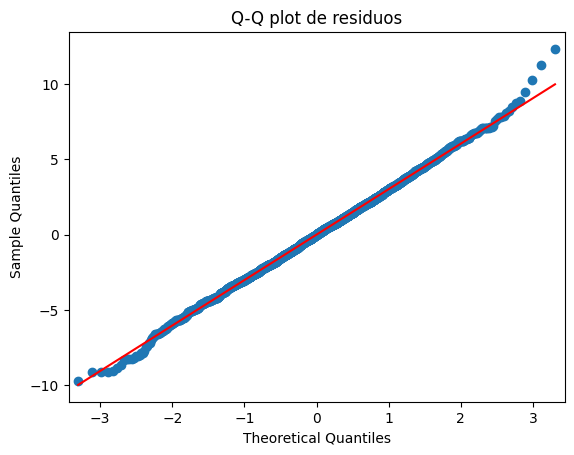

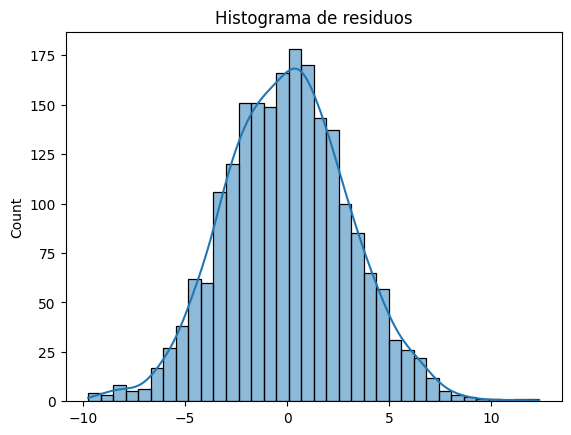

In [302]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

La distribución de los residuales es tan pero tan normal, que pasa el test de Shapiro, que con esta cantidad de datos es muy sensible. Recordemos que la prueba de hipótesis con el test de Shapiro-Wilk es:
+ $H_0$: Los residuales siguen una distribución normal
+ $H_1$: Los residuales NO siguen una distribución normal.

Se puede ver también que el Q-Q plot describe una línea recta (que sólo pasa en distribuciones normales) y se ve una clara forma de campana en el histograma.

En fin, todo lo visto grita que los residuales siguen una distribución normal. Recordemos que la base de datos es sintética. En la realidad, esto es una rareza.

### Homoscedasticidad

La homoscedasticidad la deducimos a través del test de Breusch-Pagan, en el cual tenemos:
+ $H_0$: Hay Homoscedasticidad
+ $H_1$: No hay homoscedasticidad.

Recordando que la presencia de homoscedasticidad indica que la distribución del error no depende de las condiciones de operación siempre y cuando se esté interpolando. Entonces, realizamos el test:

In [303]:
# 10. Realice la prueba de Breusch-Pagan para los residuales
# y comente el resultado.

# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2303



Dado que el `valor-p` es superior a cualquier nivel de significancia, se establece la homoscedasticidad.

### Linealidad

La linealidad no es una medida o prueba estadística que nos indique que hay linealidad. Pero hay muchas que nos lo indican de forma indirecta. El hecho de que se haya pasado el test de normalidad y el test de homoscedasticidad es un fuerte indicio. Otro indicio podríamos obtenerlo del gráfico de dispersión de datos reales vs datos hipotéticos. Esto lo realizamos mediante el siguiente código:

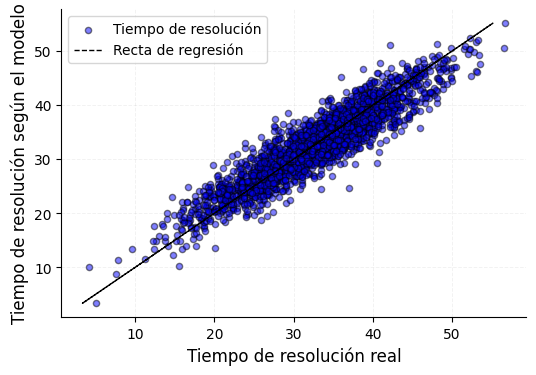

In [304]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    y, y_calculada,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.5,            # transparencia
    s=20,                 # tamaño de los puntos
    label='Tiempo de resolución' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    y_calculada, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Tiempo de resolución real',
    fontsize=12
)

plt.ylabel(
    'Tiempo de resolución según el modelo',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



En el gráfico vemos que la dispersión de puntos parecen seguir una línea recta, por lo tanto, se puede seguir suponiendo la normalidad.

## Conclusión

Dado que el modelo sigue prácticamente todos los supuestos, el modelo es muy confiable en sus predicciones. Métodos como `.predict` y `.get_predict` tendrán resultados muy cercanos a la realidad. Se puede realizar extrapolación, siempre con precausión, aunque el modelo sugier buena capacidad para extrapolación.